In [130]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa
import pandas as pd


In [131]:
def apply_vad(y, top_db, frame_length=551, hop_length=220):
    # Use librosa.effects.split to find non-silent intervals. This returns a 2xn array. which are the starting and stopping times of speech frames.
    intervals = librosa.effects.split(  y,                        
                                        top_db=top_db,                
                                        frame_length=frame_length,   
                                        hop_length=hop_length)     
    # Since some rhythym and natural pauses in speech can be used in speaker identification we only remove preceding and trailing silences.  
    start = intervals[0][0]
    end = intervals[-1][1]
    # Stitch the intervals back into one continuous speech-only array
    y_vad = np.concatenate([y[start:end]])
    return y_vad

In [132]:
def extract_fbanks(S, frame_length=551, hop_length=220):
    # Compute Mel spectrogram (power), then log-scale
    mel = librosa.feature.melspectrogram(
        S=S,            
        n_fft=frame_length,
        hop_length=hop_length,# setting the Frame size
        win_length=frame_length,# setting the Hop length
        window="hann",       # Kaldi’s default “hamming/povey” style → librosa’s “hann” is fine
        center=False,        # so frames align exactly with the 25 ms/10 ms grid
        n_mels=24,
        fmin=20,
        fmax=7600
    )
    
    return mel               

In [133]:
def sliding_window_mean_normalization(log_fbank, window_size):
    # fbank: (n_mels, n_frames)
    df = pd.DataFrame(log_fbank.T)
    normalized = df.rolling(
        window=window_size,    # number of consecutive rows in each window
        min_periods=1,         # require at least 1 row to compute a mean
        center=True            # center the window on each row, rather than “trailing” or “leading”
    ).mean() # (axis=0)  # compute mean across rows in each window

    log_fbank_norm = (df - normalized).T.values.astype(np.float32) 
    return log_fbank_norm

In [ ]:
path = "..\\0audio\\Actor_01\\03-01-01-01-01-01-01.wav"
x, sr = librosa.load(path)
ipd.Audio(x, rate=sr)


In [135]:
hop_length = 225
win_length = 550
y_vad = apply_vad(x, top_db=40, frame_length=win_length, hop_length=hop_length)
ipd.Audio(y_vad, rate=sr)

(32850,)


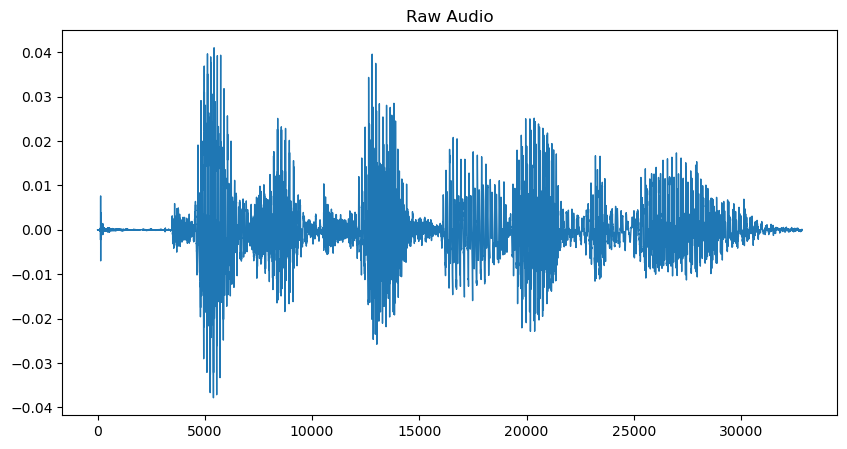

In [136]:
pd.Series(y_vad).plot(figsize=(10,5), 
                  lw=1, 
                  title='Raw Audio')
print(y_vad.shape)

(1025, 147)


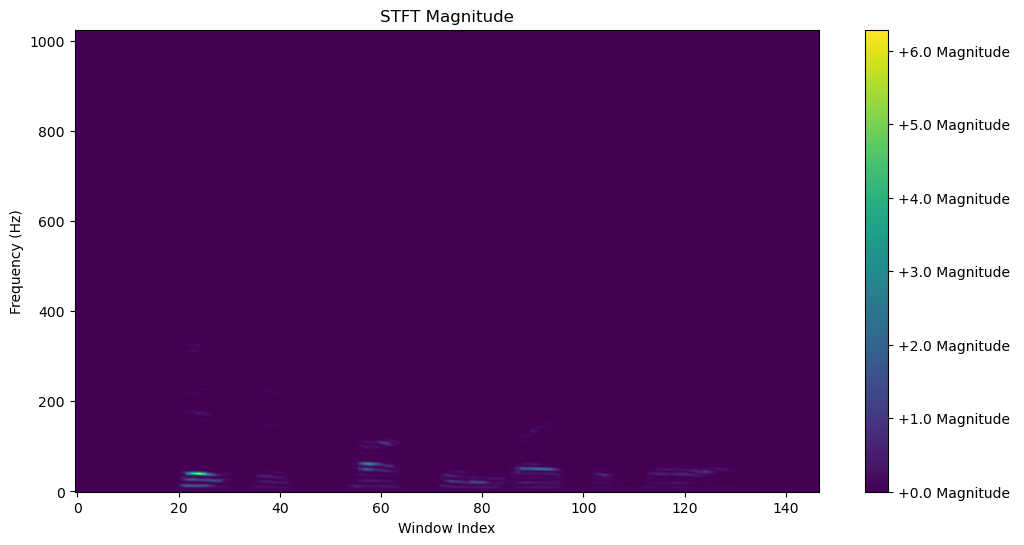

In [137]:
S = librosa.stft(y_vad, hop_length=hop_length, win_length = win_length)
S = np.abs(S**2)
print(S.shape)
plt.figure(figsize=(12, 6))
plt.imshow(S, aspect= 'auto')
plt.title('STFT Magnitude')
plt.xlabel('Window Index')
plt.ylabel('Frequency (Hz)')
plt.colorbar(format='%+2.1f Magnitude ')
plt.gca().invert_yaxis()

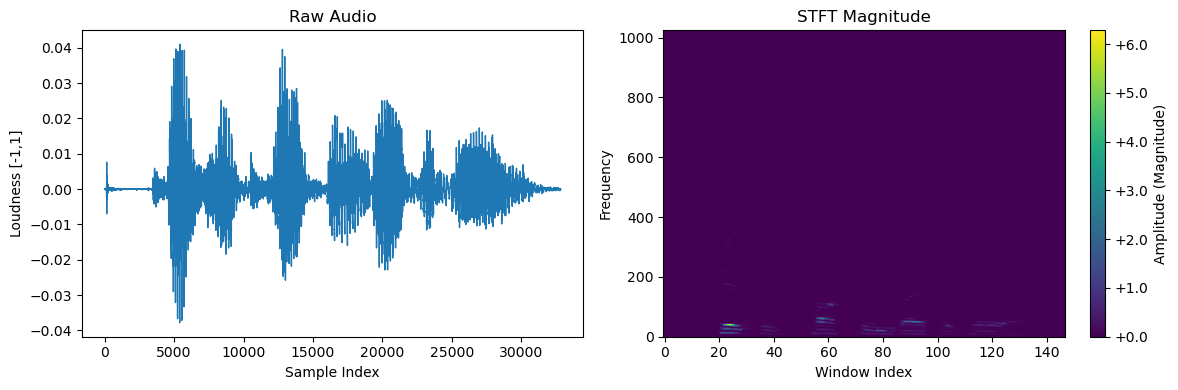

In [138]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# --- Left: Raw audio with VAD applied ---
pd.Series(y_vad).plot(
    ax=ax1,
    lw=1,
    color='C0'
)
ax1.set_title('Raw Audio')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Loudness [-1,1]')

# --- Right: STFT magnitude ---
img = ax2.imshow(
    S,
    aspect='auto',
    origin='lower',
    interpolation='none'
)
ax2.set_title('STFT Magnitude')
ax2.set_xlabel('Window Index')
ax2.set_ylabel('Frequency')
cbar = fig.colorbar(img, ax=ax2, format='%+2.1f')
cbar.set_label('Amplitude (Magnitude)')

# Tight layout and show
plt.tight_layout()
plt.show()

(24, 147)


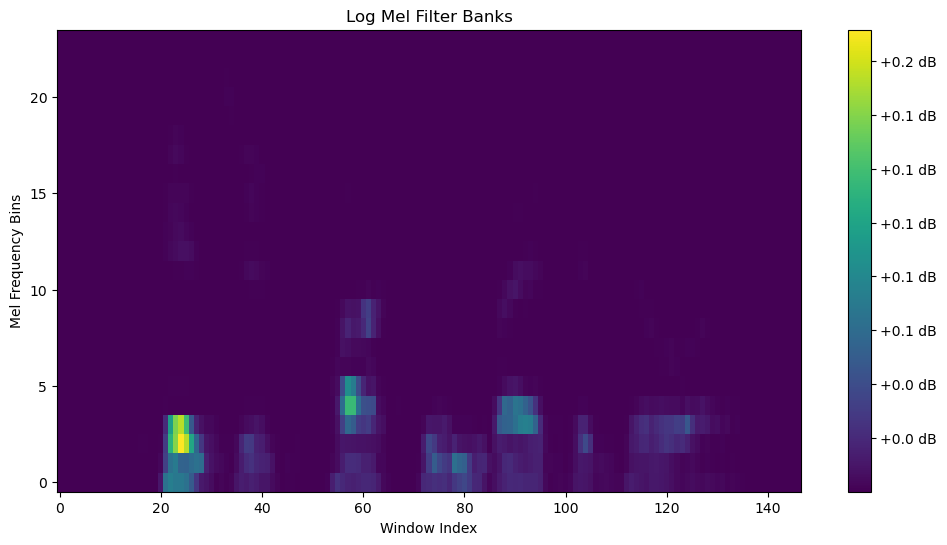

In [144]:
# Extract log Mel filter banks
mel = extract_fbanks(S, frame_length=win_length, hop_length=hop_length)
print(mel.shape)
# plot the log Mel filter banks
# set aspect to wide so that the time axis is more visible
plt.figure(figsize=(12, 6))
plt.imshow(mel, aspect='auto')
plt.title('Log Mel Filter Banks')
plt.xlabel('Window Index')
plt.ylabel('Mel Frequency Bins')
plt.colorbar(format='%+2.1f dB')
plt.gca().invert_yaxis()


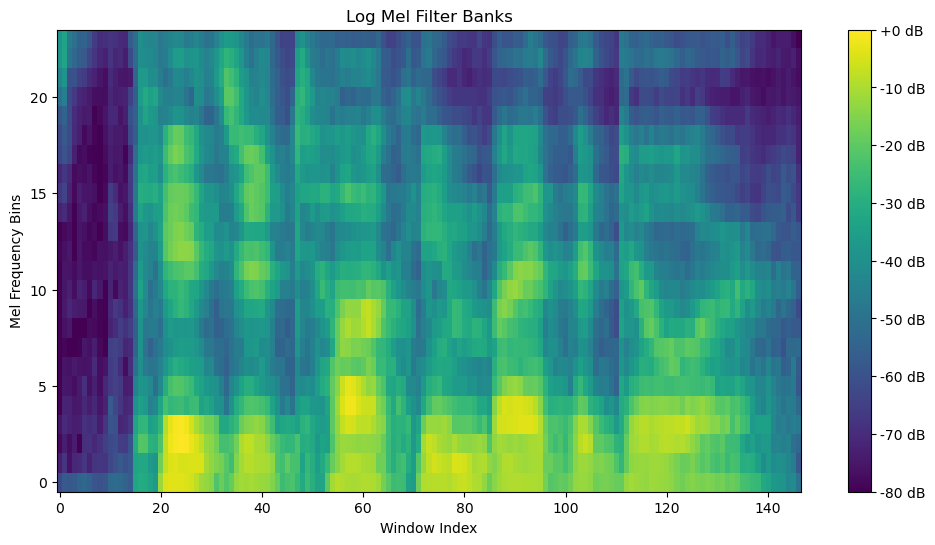

In [140]:
log_fbank = librosa.power_to_db(mel, ref=np.max)  # Apply mel filterbanks, shape: (24, n_frames)
plt.figure(figsize=(12, 6))
plt.imshow(log_fbank, aspect='auto')
plt.title('Log Mel Filter Banks')
plt.xlabel('Window Index')
plt.ylabel('Mel Frequency Bins')
plt.colorbar(format='%+2.0f dB')
plt.gca().invert_yaxis()

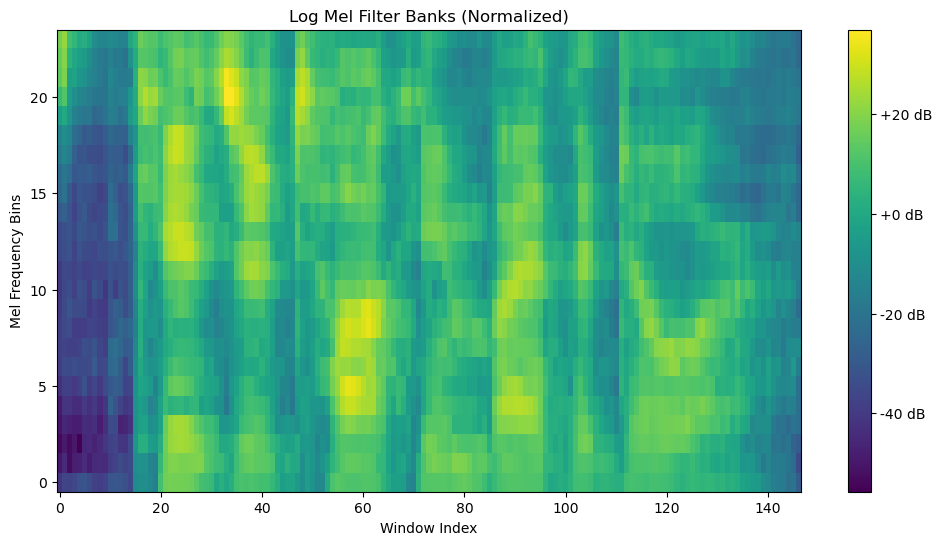

In [141]:
# Apply sliding window normalization
windw_len_seconds = 3 # length of the sliding window in seconds
# Calculate the window size in terms of frames
window_size = int(windw_len_seconds * sr / hop_length)
log_fbank_norm = sliding_window_mean_normalization(log_fbank, window_size=window_size)
# plot the log Mel filter banks
plt.figure(figsize=(12, 6))
plt.imshow(log_fbank_norm, aspect='auto')
plt.title('Log Mel Filter Banks (Normalized)')
plt.xlabel('Window Index')
plt.ylabel('Mel Frequency Bins')
plt.colorbar(format='%+2.0f dB')
plt.gca().invert_yaxis()

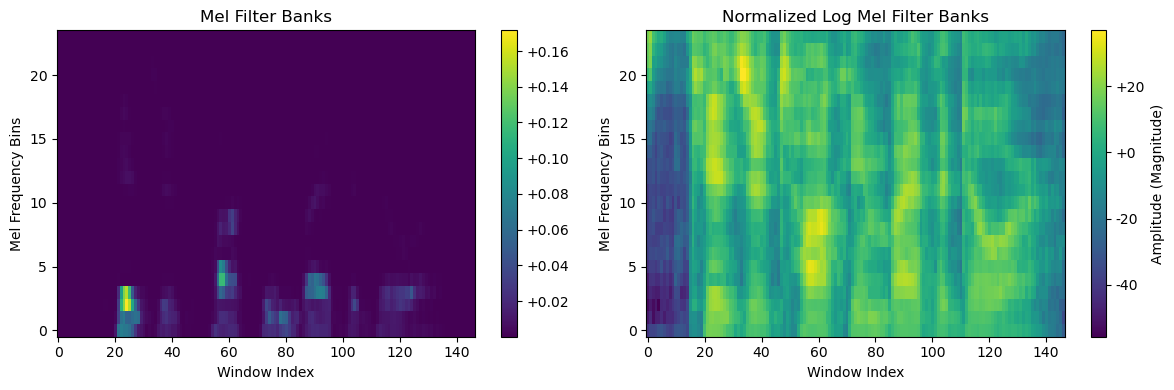

In [146]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# --- Left: Raw audio with VAD applied ---
img = ax1.imshow(
    mel,
    aspect='auto',
    origin='lower',
    interpolation='none'
)
ax1.set_title('Mel Filter Banks')
ax1.set_xlabel('Window Index')
ax1.set_ylabel('Mel Frequency Bins')
# Colorbar for the left plot
cbar = fig.colorbar(img, ax=ax1, format='%+2.2f')

# --- Right: STFT magnitude ---
img = ax2.imshow(
    log_fbank_norm,
    aspect='auto',
    origin='lower',
    interpolation='none'
)
ax2.set_title('Normalized Log Mel Filter Banks')
ax2.set_xlabel('Window Index')
ax2.set_ylabel('Mel Frequency Bins')
cbar = fig.colorbar(img, ax=ax2, format='%+2.0f')
cbar.set_label('Amplitude (Magnitude)')

# Tight layout and show
plt.tight_layout()
plt.show()